<a href="https://colab.research.google.com/github/JaneLin712/NTUT_Machine_Learning/blob/main/HW2_UNet_3D_Ignite_colab_resume.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup environment

訓練需要的套件：

- `nibabel`：讀寫 `.nii / .nii.gz`
- `ignite`：管理 PyTorch training / validation loop
- `matplotlib`：繪製 Epoch–Loss 與 Epoch–Validation Dice 曲線

訓練、驗證、繪圖與權重儲存功能。


In [ ]:
# 若尚未安裝 MONAI，可執行此 cell
!python -c "import monai" || pip install -q "monai-weekly[ignite,nibabel]"

# matplotlib 用來畫訓練曲線
!python -c "import matplotlib" || pip install -q matplotlib


Traceback (most recent call last):
  File "<string>", line 1, in <module>
    import monai
ModuleNotFoundError: No module named 'monai'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 371.8/371.8 kB 35.0 MB/s eta 0:00:00


## Setup imports

glob 與 logging → 找檔案  
os → path / directory 操作  
tempfile → 建立暫存資料夾  
shutil → 最後刪除資料夾  
nibabel 與 np → 建立、讀取、儲存 NIfTI(nii.gz)  
torch  → 模型、optimizer、GPU  
ignite  → training framework  


In [ ]:
import glob
import logging
import os
import shutil
import sys
from pathlib import Path

import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import torch
import ignite

from monai.config import print_config
from monai.data import Dataset, decollate_batch, DataLoader
from monai.handlers import MeanDice
from monai.losses import DiceLoss
from monai.networks.nets import UNet
from monai.transforms import (
    Activations,
    AsDiscrete,
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    ScaleIntensityd,
    RandCropByPosNegLabeld,
)
from monai.utils import first

print_config()


MONAI version: 1.7.dev2638
Numpy version: 2.1.3
Pytorch version: 2.11.0+cu128
MONAI flags: HAS_EXT=False, USE_COMPILED=False, USE_META_DICT=False
MONAI rev id: 43b604323beaeca5718d23b2ba4c130da08d84b8
MONAI __file__: /usr/local/lib/python3.13/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.5.5
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.4.2
scikit-image version: 0.25.2
scipy version: 1.16.3
Pillow version: 11.3.0
Tensorboard version: 2.20.0
gdown version: 5.2.2
TorchVision version: 0.26.0+cu128
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 2.2.3
einops version: 0.8.2
transformers version: 5.16.1
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://monai.readthedocs.io/en/latest/installation.ht

## Setup demo data


In [ ]:
import os
import sys
import logging

# 1. 設定路徑與基礎變數
dataset_dir = "/content/M-WHS-15"

file_id = "1roAdw6jmM9Yf6VvMDBHC0A47XFo3NQ-h"
download_path = os.path.join(dataset_dir, "M-WHS-15.zip")

print("dataset directory:", dataset_dir)
logging.basicConfig(stream=sys.stdout, level=logging.INFO)

# 2. 建立資料夾
os.makedirs(dataset_dir, exist_ok=True)

# 3. 使用 gdown 從 Google Drive 下載資料集
!pip install -q gdown
!gdown --id {file_id} -O {download_path}

print("Downloaded to:", download_path)

dataset directory: /content/M-WHS-15
/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1roAdw6jmM9Yf6VvMDBHC0A47XFo3NQ-h
From (redirected): https://drive.google.com/uc?id=1roAdw6jmM9Yf6VvMDBHC0A47XFo3NQ-h&confirm=t&uuid=d07c1825-a994-4cd4-affa-35112b5edf3a
To: /content/M-WHS-15/M-WHS-15.zip
100% 1.60G/1.60G [00:18<00:00, 86.5MB/s]
Downloaded to: /content/M-WHS-15/M-WHS-15.zip


In [ ]:
import os
import zipfile

dataset_dir = "/content/M-WHS-15"
download_path = os.path.join(dataset_dir, "M-WHS-15.zip")

with zipfile.ZipFile(download_path, "r") as zip_ref:
    zip_ref.extractall(dataset_dir)

print("Extracted files:")
for root, dirs, files in os.walk(dataset_dir):
    level = root.replace(dataset_dir, "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:10]:
        print(f"{indent}    {file}")

Extracted files:
M-WHS-15/
    M-WHS-15.zip
    dataset_15/
        21/
            21_gt.nii.gz
            21.nii.gz
        24/
            24.nii.gz
            24_gt.nii.gz
        25/
            25_gt.nii.gz
            25.nii.gz
        20/
            20.nii.gz
            20_gt.nii.gz
        08/
            08.nii.gz
            08_gt.nii.gz
        04/
            04.nii.gz
            04_gt.nii.gz
        09/
            09_gt.nii.gz
            09.nii.gz
        23/
            23.nii.gz
            23_gt.nii.gz
        22/
            22.nii.gz
            22_gt.nii.gz
        10/
            10.nii.gz
            10_gt.nii.gz
        18/
            18.nii.gz
            18_gt.nii.gz
        17/
            17.nii.gz
            17_gt.nii.gz
        12/
            12.nii.gz
            12_gt.nii.gz
        19/
            19_gt.nii.gz
            19.nii.gz
        11/
            11_gt.nii.gz
            11.nii.gz


In [ ]:
# ============================================================
# Setup M-WHS-15 image / label paths
# ============================================================

import os
import glob

dataset_root = "/content/M-WHS-15/dataset_15"

images = []
segs = []

case_dirs = sorted(glob.glob(os.path.join(dataset_root, "*")))

for case_dir in case_dirs:
    case_id = os.path.basename(case_dir)

    image_path = os.path.join(case_dir, f"{case_id}.nii.gz")
    label_path = os.path.join(case_dir, f"{case_id}_gt.nii.gz")

    if os.path.exists(image_path) and os.path.exists(label_path):
        images.append(image_path)
        segs.append(label_path)

print("Number of images:", len(images))
print("Number of labels:", len(segs))

print("\nFirst image:")
print(images[0])

print("\nFirst label:")
print(segs[0])


Number of images: 15
Number of labels: 15

First image:
/content/M-WHS-15/dataset_15/04/04.nii.gz

First label:
/content/M-WHS-15/dataset_15/04/04_gt.nii.gz


In [ ]:
import nibabel as nib
import numpy as np

for image_path, label_path in zip(images, segs):
    image = nib.load(image_path)
    label = nib.load(label_path)

    print("=" * 60)
    print("Case:", os.path.basename(os.path.dirname(image_path)))
    print("Image shape:", image.shape)
    print("Label shape:", label.shape)
    print("Image spacing:", image.header.get_zooms())
    print("Label spacing:", label.header.get_zooms())
    print("Label values:", np.unique(label.get_fdata()))


NameError: name 'images' is not defined

In [ ]:
# ============================================================
# Split M-WHS-15 into Training / Validation sets
# ============================================================

import random

random_seed = 42
val_ratio = 0.2

# 將 image / label 先配成同一筆資料
all_files = [
    {"image": image, "label": seg}
    for image, seg in zip(images, segs)
]

# 固定亂數，確保每次執行都得到相同切分
random.Random(random_seed).shuffle(all_files)

# 15 * 0.2 = 3 cases for validation
num_val = int(len(all_files) * val_ratio)

val_files = all_files[:num_val]
train_files = all_files[num_val:]

print("Total cases:", len(all_files))
print("Training cases:", len(train_files))
print("Validation cases:", len(val_files))

print("\nTraining:")
for item in train_files:
    print(item["image"])

print("\nValidation:")
for item in val_files:
    print(item["image"])


Total cases: 15
Training cases: 12
Validation cases: 3

Training:
/content/M-WHS-15/dataset_15/17/17.nii.gz
/content/M-WHS-15/dataset_15/25/25.nii.gz
/content/M-WHS-15/dataset_15/23/23.nii.gz
/content/M-WHS-15/dataset_15/12/12.nii.gz
/content/M-WHS-15/dataset_15/09/09.nii.gz
/content/M-WHS-15/dataset_15/20/20.nii.gz
/content/M-WHS-15/dataset_15/10/10.nii.gz
/content/M-WHS-15/dataset_15/11/11.nii.gz
/content/M-WHS-15/dataset_15/22/22.nii.gz
/content/M-WHS-15/dataset_15/04/04.nii.gz
/content/M-WHS-15/dataset_15/08/08.nii.gz
/content/M-WHS-15/dataset_15/21/21.nii.gz

Validation:
/content/M-WHS-15/dataset_15/19/19.nii.gz
/content/M-WHS-15/dataset_15/24/24.nii.gz
/content/M-WHS-15/dataset_15/18/18.nii.gz


## Setup transforms, dataset


In [ ]:
# Define transforms for image and segmentation
from monai.transforms import Spacingd

train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),

    EnsureChannelFirstd(keys=["image", "label"]),

    Spacingd(
        keys=["image", "label"],
        #pixdim=(0.4, 0.4, 0.5),
        pixdim=(0.7, 0.7, 1.0),
        mode=("bilinear", "nearest"),
    ),

    ScaleIntensityd(keys=["image"]),

    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(128, 128, 128),
        pos=1,
        neg=1,
        num_samples=4,
    ),
])

# # Define nifti dataset, dataloader
# ds = Dataset(
#     data=train_files,
#     transform=train_transforms
# )

# loader = DataLoader(
#     ds,
#     batch_size=1,   #2
#     num_workers=2,   #2
#     pin_memory=torch.cuda.is_available()
# )

# batch = first(loader)

# print("Batch, Channel, Spatial1, Spatial2, Spatial3")
# print("[B, C, H, W, D]")
# print(batch["image"].shape)
# print(batch["label"].shape)


## Create Model, Loss, Optimizer

全新訓練與重新開啟 Colab 後接續訓練，都要先執行前面的環境、資料集與這裡的初始化，再依序執行到 Validation 設定。
在下方 Training history cell 設定 `training_mode`；接續訓練請設為 `"resume"`。
初始化與事件註冊 cell 每次工作階段執行一次即可；同一工作階段繼續訓練可直接使用推論前的接續區塊。


In [ ]:
# Create UNet, DiceLoss and Adam optimizer
device = torch.device("cuda:0")
#device = torch.device("cpu")
net = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)


loss = DiceLoss(sigmoid=True)
lr = 1e-3
opt = torch.optim.Adam(net.parameters(), lr)


## Create supervised_trainer using ignite


In [ ]:
# Prepare dictionary batch for Ignite
def prepare_batch(batch, device, non_blocking):
    return (
        batch["image"].to(device, non_blocking=non_blocking),
        batch["label"].to(device, non_blocking=non_blocking),
    )

# Create trainer
trainer = ignite.engine.create_supervised_trainer(
    model=net,
    optimizer=opt,
    loss_fn=loss,
    device=device,
    non_blocking=False,
    prepare_batch=prepare_batch,
)


## Training history and model checkpoints

這裡只做三件事：

1. 記錄每個 Epoch 的平均 Training Loss
2. 記錄 Validation Dice
3. 儲存最佳權重與訓練完成後的最終權重


In [ ]:
dataset_dir = "/content/M-WHS-15"

In [ ]:
# 使用方式：第一次訓練選 "fresh"；從舊檔繼續選 "resume"。
# resume 模式會略過原本的全新訓練，稍後在推論前的接續 cell 載入 checkpoint。
training_mode = "fresh"
if training_mode not in ("fresh", "resume"):
    raise ValueError('training_mode 必須是 "fresh" 或 "resume"')

history = {"train_epoch": [], "train_loss": [], "val_epoch": [], "val_dice": []}
_epoch_losses = []

# Colab /content 會在執行階段刪除後消失；請下載模型檔，或掛載 Drive 後改成 Drive 路徑。
output_dir = os.path.join(dataset_dir, "training_output")
checkpoint_dir = output_dir  # 固定模型輸出位置，避免後面的推論重設 output_dir。
os.makedirs(checkpoint_dir, exist_ok=True)
best_model_path = os.path.join(checkpoint_dir, "best_model.pth")
final_model_path = None  # 儲存時依實際完成的 epoch 決定檔名。
best_val_dice = -1.0

def make_checkpoint(epoch):
    return {
        "epoch": int(epoch),
        "model_state_dict": net.state_dict(),
        "optimizer_state_dict": opt.state_dict(),
        "best_val_dice": float(best_val_dice),
        "history": {key: list(values) for key, values in history.items()},
        "epoch_length": len(train_loader),
    }

def save_final_checkpoint():
    global final_model_path
    completed_epoch = int(trainer.state.epoch)
    final_model_path = os.path.join(
        checkpoint_dir, f"final_model_{completed_epoch}epoch.pth"
    )
    torch.save(make_checkpoint(completed_epoch), final_model_path)
    print(f"已完成第 {completed_epoch} epoch，儲存至：{final_model_path}")
    return final_model_path

print("Training mode:", training_mode)
print("Checkpoint directory:", checkpoint_dir)


Training mode: fresh
Checkpoint directory: /content/M-WHS-15/training_output


In [ ]:
# ============================================================
# Record training loss for each epoch
# ============================================================

@trainer.on(ignite.engine.Events.EPOCH_STARTED)
def reset_epoch_loss(engine):
    _epoch_losses.clear()


@trainer.on(ignite.engine.Events.ITERATION_COMPLETED)
def collect_iteration_loss(engine):
    # create_supervised_trainer 的 engine.state.output 即為目前 iteration loss
    _epoch_losses.append(float(engine.state.output))


@trainer.on(ignite.engine.Events.EPOCH_COMPLETED)
def record_epoch_loss(engine):
    mean_loss = float(np.mean(_epoch_losses)) if _epoch_losses else float("nan")

    history["train_epoch"].append(engine.state.epoch)
    history["train_loss"].append(mean_loss)

    print(
        f"Epoch [{engine.state.epoch}] "
        f"Training Loss: {mean_loss:.6f}"
    )


In [ ]:
# Validation 進步時儲存 best_model.pth。
# 訓練正常完成後儲存 final_model_{實際完成epoch}epoch.pth。
# 例如第一階段完成 100 epoch → final_model_100epoch.pth。


## Validation every N epochs

每隔 `validation_every_n_epochs` 執行一次完整 Validation，計算 Mean Dice。
若本次 Dice 優於過去最佳結果，就覆寫 `best_model.pth`。


In [ ]:
from monai.inferers import sliding_window_inference
from monai.transforms import Spacingd

# ============================================================
# Validation settings
# ============================================================

validation_every_n_epochs = 10
metric_name = "Mean_Dice"

post_pred = Compose([
    Activations(sigmoid=True),
    AsDiscrete(threshold=0.5),
])

post_label = Compose([
    AsDiscrete(threshold=0.5),
])


# ============================================================
# Validation transforms
# ============================================================

val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Spacingd(
        keys=["image", "label"],
        pixdim=(0.7, 0.7, 1.0),
        mode=("bilinear", "nearest"),
    ),
    ScaleIntensityd(keys=["image"]),
])


# ============================================================
# Validation Dataset / DataLoader
# ============================================================

val_ds = Dataset(
    data=val_files,
    transform=val_transforms,
)

val_loader = DataLoader(
    val_ds,
    batch_size=1,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)


# ============================================================
# Validation step
# ============================================================

def validation_step(engine, batch):
    net.eval()

    image = batch["image"].to(device)
    label = batch["label"].to(device)

    with torch.no_grad():
        pred = sliding_window_inference(
            inputs=image,
            roi_size=(128, 128, 128),
            sw_batch_size=2,
            predictor=net,
            overlap=0.25,
        )

    pred = [post_pred(i) for i in decollate_batch(pred)]
    label = [post_label(i) for i in decollate_batch(label)]

    return pred, label


# ============================================================
# Create evaluator + Dice metric
# ============================================================

evaluator = ignite.engine.Engine(validation_step)
MeanDice().attach(evaluator, metric_name)


# ============================================================
# Run validation every N epochs
# ============================================================

@trainer.on(
    ignite.engine.Events.EPOCH_COMPLETED(every=validation_every_n_epochs)
)
def run_validation(engine):
    evaluator.run(val_loader)


# ============================================================
# Record validation Dice and save the best model
# ============================================================

@evaluator.on(ignite.engine.Events.COMPLETED)
def record_validation_result(engine):
    global best_val_dice

    current_epoch = trainer.state.epoch
    current_dice = float(engine.state.metrics[metric_name])

    history["val_epoch"].append(current_epoch)
    history["val_dice"].append(current_dice)

    print(
        f"Epoch [{current_epoch}] "
        f"Validation Mean Dice: {current_dice:.6f}"
    )

    if current_dice > best_val_dice:
        best_val_dice = current_dice

        best_checkpoint = make_checkpoint(current_epoch)
        best_checkpoint["val_dice"] = current_dice
        torch.save(best_checkpoint, best_model_path)

        print(
            f"Best model updated: Dice={current_dice:.6f}"
            f" | Saved to: {best_model_path}"
        )


## Run training loop

`fresh` 模式執行首次訓練，預設完成 100 epoch，儲存 `final_model_100epoch.pth`。
`resume` 模式只建立 Training DataLoader，不啟動首次訓練；請繼續至推論前的「接續訓練」區塊。


In [ ]:
#清空 GRAM，用於準備重新訓練
import gc
import torch

gc.collect()
torch.cuda.empty_cache()


In [ ]:
# ============================================================
# Training DataLoader
# ============================================================

train_ds = Dataset(
    data=train_files,
    transform=train_transforms,
)

train_loader = DataLoader(
    train_ds,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

In [ ]:
# 首次訓練的總 epoch 數。接續訓練的目標在下方另外設定。
max_epochs = 20
if training_mode == "fresh":
    state = trainer.run(train_loader, max_epochs=max_epochs)
    save_final_checkpoint()
    print("Best validation Dice:", best_val_dice)
    print("Best model:", best_model_path)
else:
    print("已略過首次訓練，請執行推論前的接續訓練 cells。")


Epoch [1] Training Loss: 0.821009
Epoch [2] Training Loss: 0.757638
Epoch [3] Training Loss: 0.742299
Epoch [4] Training Loss: 0.740185
Epoch [5] Training Loss: 0.732994
Epoch [6] Training Loss: 0.730750
Epoch [7] Training Loss: 0.705179
Epoch [8] Training Loss: 0.707903
Epoch [9] Training Loss: 0.684571
Epoch [10] Training Loss: 0.688734
Epoch [10] Validation Mean Dice: 0.214240
Best model updated: Dice=0.214240 | Saved to: /content/M-WHS-15/training_output/best_model.pth
Epoch [11] Training Loss: 0.663377
Epoch [12] Training Loss: 0.689865
Epoch [13] Training Loss: 0.689777
Epoch [14] Training Loss: 0.670841
Epoch [15] Training Loss: 0.702881
Epoch [16] Training Loss: 0.682732
Epoch [17] Training Loss: 0.664349
Epoch [18] Training Loss: 0.677528
Epoch [19] Training Loss: 0.656643
Epoch [20] Training Loss: 0.641693
Epoch [20] Validation Mean Dice: 0.221191
Best model updated: Dice=0.221191 | Saved to: /content/M-WHS-15/training_output/best_model.pth
已完成第 20 epoch，儲存至：/content/M-WHS-15

## Plot training curves

直接使用前面紀錄在 `history` 的數值畫圖。


In [ ]:
# ============================================================
# Epoch vs Training Loss
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(
    history["train_epoch"],
    history["train_loss"],
    marker="o",
    markersize=3,
)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# Epoch vs Validation Dice
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(
    history["val_epoch"],
    history["val_dice"],
    marker="o",
)
plt.xlabel("Epoch")
plt.ylabel("Validation Dice")
plt.title("Validation Dice vs Epoch")
plt.grid(True)
plt.tight_layout()
plt.show()


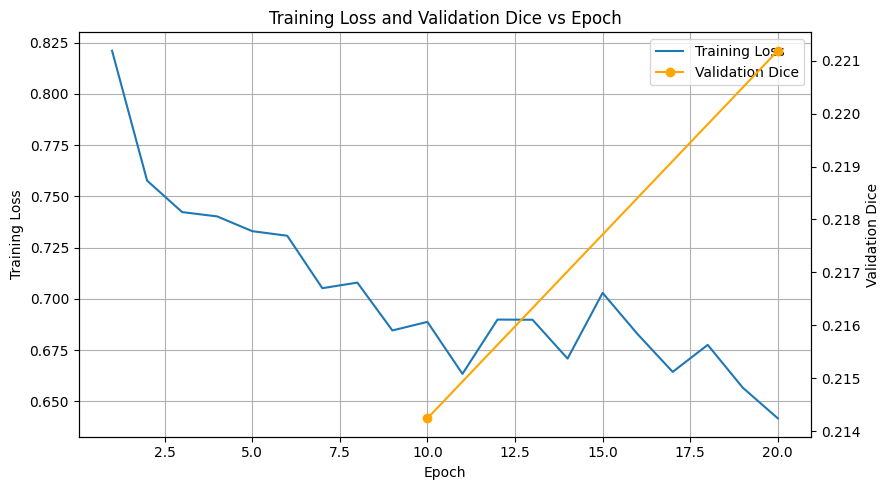

In [ ]:
# ============================================================
# Optional: show Loss and Validation Dice in one figure
# ============================================================

fig, ax1 = plt.subplots(figsize=(9, 5))

line1 = ax1.plot(
    history["train_epoch"],
    history["train_loss"],
    label="Training Loss",
)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Training Loss")
ax1.grid(True)

ax2 = ax1.twinx()
line2 = ax2.plot(
    history["val_epoch"],
    history["val_dice"],
    marker="o",
    label="Validation Dice",
    color="orange",
)
ax2.set_ylabel("Validation Dice")

lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="best")

plt.title("Training Loss and Validation Dice vs Epoch")
fig.tight_layout()
plt.show()


In [ ]:
# 若需要確認紀錄內容，可直接查看 history
history


## Saved model files

- `best_model.pth`：Validation Dice 最佳的 checkpoint，內含它實際所在的 epoch。
- `final_model_100epoch.pth`：實際完成第 100 epoch 後的 checkpoint；完成 200 時會另存 `final_model_200epoch.pth`。
- 新 checkpoint 包含模型、optimizer、epoch、最佳 Dice 與訓練曲線資料；不同 epoch 的 final 檔會保留，同 epoch 同路徑再次儲存會覆寫。
- 舊版 final 檔已有 epoch、模型與 optimizer，可直接接續，但沒有儲存的歷史曲線無法回復。

檔案位於上方的 `checkpoint_dir`。目前沒有每個 epoch 自動存檔；請讓設定的階段正常完成後保存檔案。


## 接續訓練：例如從第 100 epoch 訓練至第 200 epoch

1. **重新開啟 Colab**：先執行環境、相同資料切分、transforms、模型、optimizer、trainer、事件註冊、Validation 與 Training DataLoader；將上方 `training_mode = "resume"`，避免先跑首次訓練。**同一工作階段剛跑完 100 epoch**：可直接執行此區塊。
2. 把舊模型上傳至 Colab（或先掛載 Google Drive），修改下方 `resume_checkpoint_path`。支援此 notebook 原有格式的 `final.pth`、`final_model.pth`、`best.pth`、`best_model.pth`，檔名不影響讀取。
3. 先執行「檢查 checkpoint」cell，就能看到實際 epoch，**不會開始訓練**。`rename_legacy_final_copy = True` 可依檔案內 epoch 另存有 epoch 檔名的副本，保留舊檔。
4. 要接續時將 `run_resume_training = True`，設定 `target_total_epochs = 200`，再執行最後的接續 cell。若檔案是 100 epoch，會從 **101 跑到 200，共再跑 100 epoch**；200 是總目標，不是追加量。
5. 完成後可重新執行上方繪圖 cells，再往下推論。之後從 200 接到 300，改用 200 的檔案路徑與目標 300，重新執行檢查及接續 cells。

請用 **final** 接續最後進度；best 可能是第 80 epoch，即使上一輪已跑 100，載入 best 仍會從第 81 開始。以 checkpoint 內的 `epoch` 為準，不猜測檔名。只有權重、沒有 epoch 或 optimizer 的外部檔案會拒絕接續。

若要保留歷史最佳模型供推論，請一併上傳同一次訓練的 best 檔，並將上方 best_model_path 指向該檔（例如 best.pth）。若只上傳 final，歷史最佳 Dice 仍會恢復，但無法重建歷史最佳權重；可在推論 cell 將 inference_model_path 改成 final_model_path。

原有 optimizer 學習率會一併恢復；資料切分、batch size 與前處理請保持相同。這是 epoch 邊界的接續，並未保存所有隨機裁切/資料載入亂數狀態，因此不保證與不中斷訓練逐位元一致。

Ignite epoch 恢復方式參考：[官方 Engine 文件](https://docs.pytorch.org/ignite/generated/ignite.engine.engine.Engine.html)。


In [ ]:
# 接續設定：依實際檔案位置修改，也可以填 Google Drive 的完整路徑。
resume_checkpoint_path = os.path.join(checkpoint_dir, "/content/final_model_40epoch.pth")
target_total_epochs = 60
run_resume_training = True  # 看完下方檔案資訊後，改成 True 才會接續訓練。

# 只用於舊 final 檔：True 會建立 final_model_{epoch}epoch.pth 副本。
# 若選的是 best，請保持 False，避免把最佳模型誤標成最後模型。
rename_legacy_final_copy = False


In [ ]:
# 檢查檔案內的實際 epoch；本 cell 不啟動訓練。
from numbers import Integral

def read_training_checkpoint(path):
    if not os.path.isfile(path):
        raise FileNotFoundError(f"找不到 checkpoint，請確認上傳位置：{path}")
    ckpt = torch.load(path, map_location="cpu", weights_only=True)
    required = {"epoch", "model_state_dict", "optimizer_state_dict"}
    if not isinstance(ckpt, dict) or not required.issubset(ckpt):
        raise ValueError("需要含 epoch、model_state_dict、optimizer_state_dict 的 checkpoint。")
    if isinstance(ckpt["epoch"], bool) or not isinstance(ckpt["epoch"], Integral) or ckpt["epoch"] < 0:
        raise ValueError("checkpoint 的 epoch 必須是非負整數，無法只靠檔名判定。")
    return ckpt

if os.path.isfile(resume_checkpoint_path):
    inspected_checkpoint = read_training_checkpoint(resume_checkpoint_path)
    saved_epoch = int(inspected_checkpoint["epoch"])
    print("檔案：", resume_checkpoint_path)
    print(f"此 checkpoint 已完成第 {saved_epoch} epoch；下一個是第 {saved_epoch + 1} epoch。")
    print(f"目標 {target_total_epochs} epoch，尚需 {max(0, target_total_epochs - saved_epoch)} epoch。")
    print("有無歷史曲線：", "history" in inspected_checkpoint)
    if rename_legacy_final_copy:
        epoch_copy_path = os.path.join(checkpoint_dir, f"final_model_{saved_epoch}epoch.pth")
        if os.path.abspath(epoch_copy_path) == os.path.abspath(resume_checkpoint_path):
            print("已經是含 epoch 的檔名。")
        elif os.path.exists(epoch_copy_path):
            raise FileExistsError(f"副本已存在，未覆寫：{epoch_copy_path}")
        else:
            shutil.copy2(resume_checkpoint_path, epoch_copy_path)
            print("已建立副本：", epoch_copy_path)
    del inspected_checkpoint
else:
    print("尚未找到檔案，請先上傳並修改 resume_checkpoint_path：", resume_checkpoint_path)


檔案： /content/final_model_40epoch.pth
此 checkpoint 已完成第 40 epoch；下一個是第 41 epoch。
目標 60 epoch，尚需 20 epoch。
有無歷史曲線： True


In [ ]:
# 執行接續：保留原本 trainer 的 loss / validation 事件，不重複註冊。
if not run_resume_training:
    print("接續尚未啟動；需要時將 run_resume_training 設為 True，再執行本 cell。")
else:
    if isinstance(target_total_epochs, bool) or not isinstance(target_total_epochs, Integral):
        raise ValueError("target_total_epochs 必須是整數。")
    resume_checkpoint = read_training_checkpoint(resume_checkpoint_path)
    start_epoch = int(resume_checkpoint["epoch"])
    if target_total_epochs <= start_epoch:
        raise ValueError(f"目標必須大於已完成的 {start_epoch} epoch，沒有啟動訓練。")
    if len(train_loader) == 0:
        raise ValueError("Training DataLoader 不可為空。")
    if resume_checkpoint.get("epoch_length", len(train_loader)) != len(train_loader):
        raise ValueError("每個 epoch 的 batch 數與 checkpoint 不同，請確認資料與 batch size。")

    net.load_state_dict(resume_checkpoint["model_state_dict"])
    net.to(device)
    opt.load_state_dict(resume_checkpoint["optimizer_state_dict"])
    # PyTorch 依模型參數裝置恢復 Adam 狀態；載入後會沿用 checkpoint 的學習率。
    best_val_dice = float(resume_checkpoint.get(
        "best_val_dice", resume_checkpoint.get("val_dice", -1.0)
    ))
    saved_history = resume_checkpoint.get("history", {})
    history = {key: list(saved_history.get(key, [])) for key in
               ("train_epoch", "train_loss", "val_epoch", "val_dice")}
    if not saved_history:
        print("舊檔未記錄 history，曲線將從接續後開始，不補造先前數據。")
    _epoch_losses.clear()
    del resume_checkpoint

    # epoch 是已完成數；先恢復 100，Ignite 下一輪就會使用 101。
    # max_epochs 使用新的總目標，避免完成的舊 trainer 從 epoch 1 重新開始。
    trainer.load_state_dict({
        "epoch": start_epoch,
        "max_epochs": target_total_epochs,
        "epoch_length": len(train_loader),
    })
    net.train()
    print(f"接續第 {start_epoch + 1}～{target_total_epochs} epoch")
    print("恢復的學習率：", [group["lr"] for group in opt.param_groups])
    state = trainer.run(train_loader)
    save_final_checkpoint()
    print("Best validation Dice:", best_val_dice)
    print("可重新執行上方繪圖 cells，查看接續後曲線。")


接續第 41～60 epoch
恢復的學習率： [0.001]
Epoch [41] Training Loss: 0.597520
Epoch [42] Training Loss: 0.609514
Epoch [43] Training Loss: 0.583993
Epoch [44] Training Loss: 0.611056
Epoch [45] Training Loss: 0.593761
Epoch [46] Training Loss: 0.628416
Epoch [47] Training Loss: 0.607535
Epoch [48] Training Loss: 0.584381
Epoch [49] Training Loss: 0.566851
Epoch [50] Training Loss: 0.549651
Epoch [50] Validation Mean Dice: 0.316035
Best model updated: Dice=0.316035 | Saved to: /content/M-WHS-15/training_output/best_model.pth
Epoch [51] Training Loss: 0.590043
Epoch [52] Training Loss: 0.545384
Epoch [53] Training Loss: 0.542635
Epoch [54] Training Loss: 0.562448
Epoch [55] Training Loss: 0.603464
Epoch [56] Training Loss: 0.505133
Epoch [57] Training Loss: 0.556653
Epoch [58] Training Loss: 0.516964
Epoch [59] Training Loss: 0.613051
Epoch [60] Training Loss: 0.553815
Epoch [60] Validation Mean Dice: 0.337540
Best model updated: Dice=0.337540 | Saved to: /content/M-WHS-15/training_output/best_mode

1. 下載推論檔案(壓縮檔)
2. 解壓縮
3. 推論
4. 將推論結果輸出成csv

In [ ]:
#https://drive.google.com/file/d/1A24DgvALvbqgU8XuPNH5I29j6jK0IA4d/view?usp=drive_link
import os
import sys
import logging

# 1. 設定路徑與基礎變數
dataset_dir = "/content/M-WHS-15"
file_id = "1A24DgvALvbqgU8XuPNH5I29j6jK0IA4d"
download_path = os.path.join(dataset_dir, "pred.zip")

print("dataset directory:", dataset_dir)
logging.basicConfig(stream=sys.stdout, level=logging.INFO)

# 2. 建立資料夾
os.makedirs(dataset_dir, exist_ok=True)

# 3. 使用 gdown 從 Google Drive 下載資料集
!pip install -q gdown
!gdown --id {file_id} -O {download_path}

print("Downloaded to:", download_path)

In [ ]:
import os
import zipfile

dataset_dir = "/content/M-WHS-15"
download_path = os.path.join(dataset_dir, "pred.zip")

with zipfile.ZipFile(download_path, "r") as zip_ref:
    zip_ref.extractall(dataset_dir)

print("Extracted files:")
for root, dirs, files in os.walk(dataset_dir):
    level = root.replace(dataset_dir, "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:10]:
        print(f"{indent}    {file}")

In [ ]:
# ============================================================
# Inference for ALL CTs under PRED_DIR
#
# Example:
# PRED_DIR/
# ├── 04/
# │   └── 04.nii.gz
# ├── 05/
# │   └── 05.nii.gz
# └── 06/
#     └── 06.nii.gz
#
# Output:
# PRED_DIR/
# ├── 04/
# │   ├── 04.nii.gz
# │   └── 04_gt.nii.gz
# ├── 05/
# │   ├── 05.nii.gz
# │   └── 05_gt.nii.gz
# └── 06/
#     ├── 06.nii.gz
#     └── 06_gt.nii.gz
# ============================================================


import os
import glob
import numpy as np
import torch
import nibabel as nib

from nibabel.processing import resample_from_to

from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Spacingd,
    ScaleIntensityd,
)

from monai.inferers import sliding_window_inference


# ============================================================
# 1. Settings
# ============================================================

# 修改成你的 prediction 資料夾
PRED_DIR = "/content/M-WHS-15/pred"

# 必須與 training / validation 相同
TARGET_SPACING = (0.7, 0.7, 1.0)

# Sliding Window 設定
ROI_SIZE = (128, 128, 128)
SW_BATCH_SIZE = 2
OVERLAP = 0.25

# Binary segmentation threshold
THRESHOLD = 0.5


# ============================================================
# 2. Device
# ============================================================

device = torch.device(
    "cuda:0"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)


# ============================================================
# 3. Load BEST trained model
#
# best_model_path 在前面的 Training Cell 已經定義
# ============================================================

print()
# 預設仍使用 best；若只有 final 或要推論最後模型，改成 final_model_path
# 或直接填入 "/content/.../final_model_200epoch.pth"。
inference_model_path = best_model_path
if not inference_model_path or not os.path.isfile(inference_model_path):
    raise FileNotFoundError("找不到推論模型，請設定 inference_model_path；可改成 final_model_path。")
print("Loading model:")
print(inference_model_path)

checkpoint = torch.load(
    inference_model_path,
    map_location=device,
)

net.load_state_dict(
    checkpoint["model_state_dict"]
)

net = net.to(device)

net.eval()


# 顯示 checkpoint 資訊
print()
print("Model loaded successfully.")

if "epoch" in checkpoint:
    print(
        "Loaded model epoch:",
        checkpoint["epoch"],
    )

if "val_dice" in checkpoint:
    print(
        "Validation Dice:",
        checkpoint["val_dice"],
    )

elif "best_val_dice" in checkpoint:
    print(
        "Best Validation Dice:",
        checkpoint["best_val_dice"],
    )


# ============================================================
# 4. Inference transforms
#
# 注意：
# 推論不需要 RandCrop / RandFlip 等 augmentation
#
# 只保留和 Validation 相同的 preprocessing
# ============================================================

infer_transforms = Compose([

    LoadImaged(
        keys=["image"]
    ),

    EnsureChannelFirstd(
        keys=["image"]
    ),

    # --------------------------------------------------------
    # 必須與 Training / Validation 相同
    # --------------------------------------------------------

    Spacingd(
        keys=["image"],
        pixdim=TARGET_SPACING,
        mode="bilinear",
    ),

    # --------------------------------------------------------
    # 必須與 Training / Validation 相同
    # --------------------------------------------------------

    ScaleIntensityd(
        keys=["image"]
    ),
])


# ============================================================
# 5. Find ALL CT files
# ============================================================

input_files = sorted(

    glob.glob(

        os.path.join(
            PRED_DIR,
            "**",
            "*.nii.gz",
        ),

        recursive=True,
    )
)


# ============================================================
# 避免把之前產生的 prediction 再拿來預測
# ============================================================

input_files = [

    f for f in input_files

    if not f.endswith(
        "_gt.nii.gz"
    )
]


print()
print("=" * 60)

print(
    f"Found {len(input_files)} CT(s)"
)

print("=" * 60)


for f in input_files:

    print(
        " ",
        f
    )


# ============================================================
# 6. Check files
# ============================================================

if len(input_files) == 0:

    raise RuntimeError(
        f"No .nii.gz files found under:\n{PRED_DIR}"
    )


# ============================================================
# 7. Model inference mode
# ============================================================

net.eval()


# ============================================================
# 8. Predict every CT
# ============================================================

for idx, input_path in enumerate(
    input_files,
    start=1,
):

    print()
    print("=" * 60)

    print(
        f"[{idx}/{len(input_files)}]"
    )

    print(
        "Processing:",
        input_path,
    )

    print("=" * 60)


    # ========================================================
    # Read ORIGINAL CT
    # ========================================================

    original_nii = nib.load(
        input_path
    )

    original_shape = (
        original_nii.shape
    )

    original_affine = (
        original_nii.affine
    )

    original_spacing = (
        original_nii
        .header
        .get_zooms()[:3]
    )


    print(
        "Original shape   :",
        original_shape,
    )

    print(
        "Original spacing :",
        original_spacing,
    )


    # ========================================================
    # Preprocessing
    # ========================================================

    data = infer_transforms({

        "image":
            input_path

    })


    image = data["image"]


    # ========================================================
    # 保存 Spacingd 之後的 affine
    #
    # MONAI MetaTensor:
    #
    # [C, H, W, D]
    # ========================================================

    resampled_affine = (
        image.affine
        .detach()
        .cpu()
        .numpy()
    )


    print(
        "Resampled shape  :",
        tuple(image.shape),
    )


    # ========================================================
    # [C, H, W, D]
    #
    # →
    #
    # [B, C, H, W, D]
    # ========================================================

    image = (
        image
        .unsqueeze(0)
        .to(device)
    )


    # ========================================================
    # Sliding Window Inference
    # ========================================================

    with torch.no_grad():

        pred = sliding_window_inference(

            inputs=image,

            roi_size=ROI_SIZE,

            sw_batch_size=SW_BATCH_SIZE,

            predictor=net,

            overlap=OVERLAP,
        )


        # ----------------------------------------------------
        # logits
        # →
        # sigmoid probability
        # ----------------------------------------------------

        pred = torch.sigmoid(
            pred
        )


        # ----------------------------------------------------
        # probability
        # →
        # binary mask
        # ----------------------------------------------------

        pred = (

            pred > THRESHOLD

        ).to(
            torch.uint8
        )


    # ========================================================
    # GPU → CPU
    # ========================================================

    pred_np = (

        pred[0, 0]

        .detach()

        .cpu()

        .numpy()

        .astype(
            np.uint8
        )
    )


    print(
        "Foreground voxels before restoring:",
        int(pred_np.sum()),
    )


    # ========================================================
    # Create prediction in RESAMPLED space
    # ========================================================

    pred_resampled_nii = (
        nib.Nifti1Image(

            pred_np,

            resampled_affine,
        )
    )


    # ========================================================
    # Restore prediction to ORIGINAL CT space
    #
    # 非常重要：
    #
    # Model Prediction:
    # spacing = (0.7, 0.7, 1.0)
    #
    # ↓
    #
    # Original CT:
    # original shape
    # original spacing
    # original affine
    #
    #
    # order = 0
    #
    # segmentation 必須使用
    # Nearest Neighbor
    #
    # 不能使用 linear interpolation
    # ========================================================

    pred_original_space = (
        resample_from_to(

            pred_resampled_nii,

            (
                original_shape,
                original_affine,
            ),

            order=0,
        )
    )


    # ========================================================
    # Convert to numpy
    # ========================================================

    pred_original_np = (

        pred_original_space

        .get_fdata()

        .astype(
            np.uint8
        )
    )


    # ========================================================
    # 再確保一次只有 0 / 1
    # ========================================================

    pred_original_np = (

        pred_original_np > 0

    ).astype(
        np.uint8
    )


    # ========================================================
    # Output path
    #
    # Example:
    #
    # 04.nii.gz
    #
    # →
    #
    # 04_pred.nii.gz
    # ========================================================

    filename = os.path.basename(
        input_path
    )


    if filename.endswith(
        ".nii.gz"
    ):

        case_name = (
            filename[:-7]
        )

    else:

        case_name = (
            os.path.splitext(
                filename
            )[0]
        )


    output_dir = (
        os.path.dirname(
            input_path
        )
    )


    output_path = (

        os.path.join(

            output_dir,

            f"{case_name}_gt.nii.gz",
        )
    )


    # ========================================================
    # Save prediction
    #
    # 使用：
    #
    # Original affine
    # Original header
    #
    # 確保輸出可以直接和原始 CT 對齊
    # ========================================================

    output_header = (
        original_nii
        .header
        .copy()
    )


    output_header.set_data_dtype(
        np.uint8
    )


    output_nii = nib.Nifti1Image(

        pred_original_np,

        original_affine,

        header=output_header,
    )


    output_nii.set_data_dtype(
        np.uint8
    )


    nib.save(

        output_nii,

        output_path,
    )


    # ========================================================
    # Check SAVED result
    # ========================================================

    saved_nii = nib.load(
        output_path
    )


    print()

    print(
        "Saved:",
        output_path,
    )


    print(
        "Prediction shape   :",
        saved_nii.shape,
    )


    print(
        "Prediction spacing :",
        saved_nii
        .header
        .get_zooms()[:3],
    )


    print(
        "Foreground voxels  :",
        int(
            pred_original_np.sum()
        ),
    )


    # ========================================================
    # Sanity Check
    #
    # 預測結果應該和原始 CT：
    #
    # shape 相同
    # spacing 相同
    # ========================================================

    assert (
        saved_nii.shape
        ==
        original_shape
    ), (
        "ERROR: Prediction shape "
        "does not match original CT!"
    )


    print(
        "Shape check        : OK"
    )


    # ========================================================
    # Release temporary tensors
    # ========================================================

    del image
    del pred


    if torch.cuda.is_available():

        torch.cuda.empty_cache()


# ============================================================
# Finished
# ============================================================

print()
print("=" * 60)

print(
    "All inference finished!"
)

print("=" * 60)


In [ ]:
# ============================================================
# Convert ALL *_gt.nii.gz files under PRED_DIR
# into Kaggle submission.csv
#
# Example:
# PRED_DIR/
# ├── 04/
# │   └── 04_gt.nii.gz
# ├── 05/
# │   └── 05_gt.nii.gz
# └── 06/
#     └── 06_gt.nii.gz
#
# Output:
# submission.csv
#
# CSV format:
# Id, Predicted
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import nibabel as nib


# ============================================================
# 1. Settings
# ============================================================

# 改成你的 pred 資料夾
PRED_DIR = "/content/M-WHS-15/pred"

# CSV 輸出位置
OUTPUT_CSV = os.path.join(
    PRED_DIR,
    "submission.csv",
)


# ============================================================
# 2. RLE Encoder
#
# Binary mask:
# 0 = background
# 1 = foreground
#
# Fortran order:
# X dimension changes fastest
# ============================================================

def rle_encode(mask):

    # --------------------------------------------------------
    # 確保是 binary mask
    # --------------------------------------------------------

    mask = (
        mask > 0
    ).astype(np.uint8)


    # --------------------------------------------------------
    # Flatten using Fortran order
    # --------------------------------------------------------

    pixels = mask.flatten(
        order="F"
    )


    # --------------------------------------------------------
    # 在前後補 0
    #
    # 方便找出 run 的開始和結束位置
    # --------------------------------------------------------

    pixels = np.concatenate([
        np.array([0], dtype=np.uint8),
        pixels,
        np.array([0], dtype=np.uint8),
    ])


    # --------------------------------------------------------
    # 找 foreground 狀態改變的位置
    # --------------------------------------------------------

    runs = np.where(
        pixels[1:] != pixels[:-1]
    )[0] + 1


    # --------------------------------------------------------
    # Kaggle RLE:
    #
    # start length start length ...
    #
    # 將 end position
    # 轉換成 run length
    # --------------------------------------------------------

    runs[1::2] -= runs[::2]


    # --------------------------------------------------------
    # Convert to string
    # --------------------------------------------------------

    return " ".join(
        str(x)
        for x in runs
    )


# ============================================================
# 3. Find ALL *_gt.nii.gz files
# ============================================================

gt_files = sorted(

    glob.glob(

        os.path.join(
            PRED_DIR,
            "**",
            "*_gt.nii.gz",
        ),

        recursive=True,
    )
)


print(
    f"Found {len(gt_files)} GT file(s):"
)

for f in gt_files:

    print(
        " ",
        f
    )


# ============================================================
# 4. Check files
# ============================================================

if len(gt_files) == 0:

    raise RuntimeError(
        f"No *_gt.nii.gz files found under:\n{PRED_DIR}"
    )


# ============================================================
# 5. Convert every NIfTI to RLE
# ============================================================

rows = []


for idx, filepath in enumerate(
    gt_files,
    start=1,
):

    print()
    print("=" * 60)

    print(
        f"[{idx}/{len(gt_files)}]"
    )

    print(
        "Processing:",
        filepath
    )


    # --------------------------------------------------------
    # Read NIfTI
    # --------------------------------------------------------

    nii = nib.load(
        filepath
    )

    mask = np.asanyarray(
        nii.dataobj
    )


    # --------------------------------------------------------
    # Convert to binary
    # --------------------------------------------------------

    mask = (
        mask > 0
    ).astype(np.uint8)


    print(
        "Shape             :",
        mask.shape
    )

    print(
        "Foreground voxels :",
        int(mask.sum())
    )


    # --------------------------------------------------------
    # Filename:
    #
    # 04_gt.nii.gz
    #
    # →
    #
    # Id = 04
    # --------------------------------------------------------

    filename = os.path.basename(
        filepath
    )


    if filename.endswith(
        "_gt.nii.gz"
    ):

        case_id = filename[
            :-len("_gt.nii.gz")
        ]

    else:

        raise ValueError(
            f"Unexpected filename: {filename}"
        )


    # --------------------------------------------------------
    # RLE Encoding
    # --------------------------------------------------------

    encoded = rle_encode(
        mask
    )


    print(
        "Id                :",
        case_id
    )

    print(
        "RLE length        :",
        len(encoded)
    )


    # --------------------------------------------------------
    # Save row
    # --------------------------------------------------------

    rows.append({

        "Id":
            case_id,

        "Predicted":
            encoded,
    })


# ============================================================
# 6. Create DataFrame
# ============================================================

submission_df = pd.DataFrame(
    rows,
    columns=[
        "Id",
        "Predicted",
    ],
)


# ============================================================
# 7. Sort by Id
#
# 讓 04, 05, 06...
# 順序比較漂亮
# ============================================================

submission_df["_sort_id"] = pd.to_numeric(
    submission_df["Id"],
    errors="coerce",
)

submission_df = (
    submission_df
    .sort_values(
        by="_sort_id"
    )
    .drop(
        columns=["_sort_id"]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 8. Save submission.csv
# ============================================================

submission_df.to_csv(
    OUTPUT_CSV,
    index=False,
)


# ============================================================
# 9. Show result
# ============================================================

print()
print("=" * 60)

print(
    "Submission CSV saved:"
)

print(
    OUTPUT_CSV
)

print("=" * 60)

display(
    submission_df
)